# Generative Models — From Scratch

## 06 — Diffusion Fundamentals

> **Goal:** understand the mathematical and probabilistic foundations behind diffusion models before building a full DDPM.

This notebook is the first of two diffusion notebooks:

```text
06 — Diffusion Fundamentals
07 — DDPM From Scratch
```

The main story is:

```text
Denoising Autoencoder
        ↓
Iterative Denoising
        ↓
Markov Chain
        ↓
Forward Diffusion
        ↓
Gaussian Transition
        ↓
Reparameterization
        ↓
Closed-Form q(x_t | x_0)
        ↓
β_t, α_t, ᾱ_t
        ↓
Noise Schedule
        ↓
Reverse Diffusion
        ↓
p_θ(x_{t-1} | x_t)
        ↓
Noise Prediction ε_θ(x_t, t)
        ↓
DDPM Objective
```

By the end, the key equation should feel natural rather than memorized:

$$
x_t = \sqrt{\bar{\alpha}_t}x_0 + \sqrt{1-\bar{\alpha}_t}\epsilon
$$

## What this notebook will and will not do

We **will** build the forward diffusion mathematics, verify it numerically, visualize noise schedules, and connect the equations to the reverse generative process.

We **will not** train a full U-Net or implement the complete DDPM reverse sampler yet.

```text
Notebook 06
    Understand the mathematics.

Notebook 07
    Build the model.
```

# 1. From Denoising to Diffusion

A useful starting point is a **denoising autoencoder**.

```text
clean x
  ↓
add noise
  ↓
noisy x̃
  ↓
neural network
  ↓
reconstructed x̂
```

The basic learning problem is:

```text
noisy → clean
```

Now ask a generative question:

> What if we repeat denoising many times, starting from almost pure noise?

That idea leads to diffusion models.

## Forward vs reverse

The process is easier to remember as two directions:

```text
Forward diffusion:
clean data → gradually noisier data

Reverse diffusion:
pure noise → gradually cleaner data
```

Using timestep notation:

```text
x₀ → x₁ → x₂ → ... → x_T
```

and, during generation:

```text
x_T → x_{T-1} → ... → x₁ → x₀
```

The forward process is fixed by us. The reverse process is what the model must learn.

# 2. Why One-Step Denoising Is Not Enough

A direct mapping such as

```text
random noise → clean image
```

asks one network to bridge a very large gap.

Diffusion instead decomposes generation into many smaller transitions:

```text
very noisy
    ↓
slightly less noisy
    ↓
...
    ↓
almost clean
    ↓
data
```

Each reverse step only needs to handle the local denoising problem associated with its timestep.

This is an important **design idea**, not a guarantee that diffusion is better for every task or dataset.

# 3. Markov Chain Intuition

The forward process is modeled as a **Markov chain**:

```text
x₀ → x₁ → x₂ → x₃ → ... → x_T
```

The Markov property says that the next state only needs the current state:

$$
q(x_t \mid x_{0:t-1}) = q(x_t \mid x_{t-1})
$$

So `x_t` does not need the whole history explicitly.

Why is this useful?

- The process becomes local.
- The full probability can be factorized into simple transitions.
- Each transition can be written as a small Gaussian corruption step.

### A useful notation check

`x_{0:t-1}` means the sequence of states:

```text
x₀, x₁, ..., x_{t-1}
```

The Markov assumption lets us replace that whole history with just `x_{t-1}` when describing the next transition.

# 4. Forward Diffusion Process

A standard diffusion transition is defined as:

$$
q(x_t\mid x_{t-1}) = \mathcal N\left(x_t;\sqrt{\alpha_t}x_{t-1},(1-\alpha_t)I\right)
$$

We define:

$$
\alpha_t = 1-\beta_t
$$

so:

$$
1-\alpha_t = \beta_t
$$

and the same transition can be written as:

$$
q(x_t\mid x_{t-1}) = \mathcal N\left(x_t;\sqrt{\alpha_t}x_{t-1},\beta_t I\right)
$$

## Reading every symbol

| Symbol | Meaning |
|---|---|
| $t$ | current diffusion timestep |
| $x_{t-1}$ | previous state |
| $x_t$ | current, slightly noisier state |
| $\beta_t$ | variance of newly added noise at step $t$ |
| $\alpha_t=1-\beta_t$ | local signal retention factor |
| $I$ | identity matrix, meaning isotropic Gaussian noise |
| $\mathcal N(\mu,\Sigma)$ | Gaussian with mean $\mu$ and covariance $\Sigma$ |

The mean moves the current sample toward a scaled version of the previous sample, while the covariance injects random noise.

# 5. Why Does √β_t Appear?

A Gaussian sample can be written as:

$$
x = \mu + \sigma\epsilon, \qquad \epsilon\sim\mathcal N(0,I)
$$

Here:

```text
σ² = variance
σ  = standard deviation
```

For diffusion:

$$
\text{variance} = \beta_t
$$

therefore:

$$
\text{standard deviation} = \sqrt{\beta_t}
$$

So the sampling equation is:

$$
x_t = \sqrt{\alpha_t}x_{t-1}+\sqrt{\beta_t}\epsilon_t
$$

Using $\beta_t=1-\alpha_t$ gives:

$$
x_t = \sqrt{\alpha_t}x_{t-1}+\sqrt{1-\alpha_t}\epsilon_t
$$

> **Key point:** $\beta_t$ controls **variance**, while $\sqrt{\beta_t}$ is the coefficient multiplying standard Gaussian noise.

In [1]:
# Tiny variance-vs-standard-deviation sanity check
beta_t = 0.04
variance = beta_t
std = beta_t ** 0.5

print(f"beta_t (variance)           = {variance:.2f}")
print(f"sqrt(beta_t) (std)          = {std:.2f}")
print(f"std^2                        = {std**2:.2f}")

beta_t (variance)           = 0.04
sqrt(beta_t) (std)          = 0.20
std^2                        = 0.04


# 6. Reparameterization Trick

The forward transition is conveniently sampled through:

$$
x_t = \sqrt{\alpha_t}x_{t-1}+\sqrt{1-\alpha_t}\epsilon_t,
\qquad \epsilon_t\sim\mathcal N(0,I)
$$

Instead of treating the Gaussian sample as a mysterious black box, we make the randomness explicit:

```text
x_{t-1}
   │
   ├── multiply by √α_t ──┐
   │                      │
noise ε_t                 +
   │                      │
   └─ multiply by √(1-α_t)
                          │
                          ↓
                         x_t
```

This form is useful because it cleanly separates the deterministic transformation from the random source.

# 7. Toy Numerical Example

Take a scalar example:

```text
x₀   = 2.0
α₁   = 0.81
ε₁   = 0.5
```

Then:

$$
x_1=\sqrt{0.81}(2.0)+\sqrt{0.19}(0.5)
$$

The square-root coefficients matter: one comes from signal retention, the other from the standard deviation of the added Gaussian noise.

In [2]:
import math

x0 = 2.0
alpha_1 = 0.81
epsilon_1 = 0.5

x1 = math.sqrt(alpha_1) * x0 + math.sqrt(1.0 - alpha_1) * epsilon_1

print(f"x0 = {x0}")
print(f"alpha_1 = {alpha_1}")
print(f"epsilon_1 = {epsilon_1}")
print(f"sqrt(alpha_1) = {math.sqrt(alpha_1):.4f}")
print(f"sqrt(1-alpha_1) = {math.sqrt(1-alpha_1):.4f}")
print(f"x1 = {x1:.4f}")

x0 = 2.0
alpha_1 = 0.81
epsilon_1 = 0.5
sqrt(alpha_1) = 0.9000
sqrt(1-alpha_1) = 0.4359
x1 = 2.0179


You can already see the qualitative behavior: the old signal is scaled, and fresh randomness is added. Repeating this operation gradually destroys information about the original sample.

# 8. From One Step to Many Steps

One step is:

$$
x_t=\sqrt{\alpha_t}x_{t-1}+\sqrt{1-\alpha_t}\epsilon_t
$$

For the first two steps:

$$
x_1=\sqrt{\alpha_1}x_0+\sqrt{1-\alpha_1}\epsilon_1
$$

$$
x_2=\sqrt{\alpha_2}x_1+\sqrt{1-\alpha_2}\epsilon_2
$$

Now substitute $x_1$ into $x_2$:

$$
x_2=\sqrt{\alpha_2}\left(\sqrt{\alpha_1}x_0+\sqrt{1-\alpha_1}\epsilon_1\right)+\sqrt{1-\alpha_2}\epsilon_2
$$

Distribute the coefficient:

$$
x_2=\sqrt{\alpha_2\alpha_1}x_0 + \sqrt{\alpha_2(1-\alpha_1)}\epsilon_1 + \sqrt{1-\alpha_2}\epsilon_2
$$

This expression is the key bridge from a single transition to the closed form.

# 9. Deriving the Closed Form $q(x_t\mid x_0)$

Define the cumulative product:

$$
\bar{\alpha}_t=\prod_{s=1}^{t}\alpha_s
$$

Read this as:

```text
ᾱ_t = α₁ × α₂ × ... × α_t
```

It tracks how much of the original signal survives after **all** previous steps.

The goal is to show that many local Gaussian transitions can be collapsed into one direct Gaussian transition:

$$
q(x_t\mid x_0)=\mathcal N\left(x_t;\sqrt{\bar\alpha_t}x_0,(1-\bar\alpha_t)I\right)
$$

and therefore:

$$
x_t=\sqrt{\bar\alpha_t}x_0+\sqrt{1-\bar\alpha_t}\epsilon,
\qquad \epsilon\sim\mathcal N(0,I)
$$

We will first prove the two-step case explicitly.

# 10. The $t=2$ Case, Carefully

We reached:

$$
x_2=\sqrt{\alpha_1\alpha_2}x_0 + \sqrt{\alpha_2(1-\alpha_1)}\epsilon_1 + \sqrt{1-\alpha_2}\epsilon_2
$$

The two noise variables are independent:

$$
\epsilon_1,\epsilon_2\sim\mathcal N(0,I)
$$

A weighted sum of independent Gaussian variables is still Gaussian. Therefore the two noise terms can be merged into one Gaussian variable. The key thing to compute is the total variance.

## Add the two noise variances

The first weighted noise term has variance:

$$
\alpha_2(1-\alpha_1)
$$

The second has variance:

$$
1-\alpha_2
$$

Because the noise terms are independent, variances add:

$$
\alpha_2(1-\alpha_1)+(1-\alpha_2)
$$

Expand:

$$
\alpha_2-\alpha_2\alpha_1+1-\alpha_2
$$

Cancel $+\alpha_2$ with $-\alpha_2$:

$$
1-\alpha_1\alpha_2
$$

So the whole expression can be written using **one** standard Gaussian:

$$
x_2=\sqrt{\alpha_1\alpha_2}x_0+\sqrt{1-\alpha_1\alpha_2}\epsilon
$$

But:

$$
\bar\alpha_2=\alpha_1\alpha_2
$$

Therefore:

$$
x_2=\sqrt{\bar\alpha_2}x_0+\sqrt{1-\bar\alpha_2}\epsilon
$$

## Generalizing the pattern

The same algebra continues for later timesteps. Every new step multiplies the original signal coefficient by one more $\sqrt{\alpha_t}$, so the product becomes:

$$
\sqrt{\alpha_1\alpha_2\cdots\alpha_t}=\sqrt{\bar\alpha_t}
$$

At the same time, the accumulated Gaussian noise has total variance:

$$
1-\bar\alpha_t
$$

So the general closed form is:

$$
\boxed{
q(x_t\mid x_0)=\mathcal N\left(x_t;\sqrt{\bar\alpha_t}x_0,(1-\bar\alpha_t)I\right)
}
$$

and the sampling form is:

$$
\boxed{
x_t=\sqrt{\bar\alpha_t}x_0+\sqrt{1-\bar\alpha_t}\epsilon
}
$$

with:

$$
\epsilon\sim\mathcal N(0,I)
$$

# 11. α_t, β_t, and ᾱ_t Cheat Sheet

| Symbol | Meaning |
|---|---|
| $\beta_t$ | noise **variance** added at step $t$ |
| $\alpha_t=1-\beta_t$ | signal retention factor at step $t$ |
| $\bar\alpha_t=\prod_{s=1}^{t}\alpha_s$ | cumulative signal retention |
| $1-\bar\alpha_t$ | cumulative noise variance |

A useful dependency chain is:

```text
β_t
 ↓
α_t = 1 - β_t
 ↓
ᾱ_t = Π α_s
 ↓
x_t = √ᾱ_t x₀ + √(1-ᾱ_t) ε
```

# 12. Implementing the Forward Process in PyTorch

Now we translate the equations into a small, reusable implementation.

The schedule is intentionally simple:

```text
T = 100
β_start = 1e-4
β_end   = 0.02
```

We will precompute the schedule quantities once, then use them repeatedly.

In [3]:
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
from torch import nn
from torch.utils.data import DataLoader

from torchvision import datasets, transforms

SEED = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("Device:", DEVICE)

Device: cuda


In [4]:
# Basic diffusion schedule
T = 100
BETA_START = 1e-4
BETA_END = 0.02

betas = torch.linspace(BETA_START, BETA_END, T, dtype=torch.float32)
alphas = 1.0 - betas
alpha_bars = torch.cumprod(alphas, dim=0)

sqrt_alphas = torch.sqrt(alphas)
sqrt_alpha_bars = torch.sqrt(alpha_bars)
sqrt_one_minus_alpha_bars = torch.sqrt(1.0 - alpha_bars)

print("betas shape:", betas.shape)
print("alphas shape:", alphas.shape)
print("alpha_bars shape:", alpha_bars.shape)
print("alpha_bar[0]:", alpha_bars[0].item())
print("alpha_bar[-1]:", alpha_bars[-1].item())

betas shape: torch.Size([100])
alphas shape: torch.Size([100])
alpha_bars shape: torch.Size([100])
alpha_bar[0]: 0.9998999834060669
alpha_bar[-1]: 0.3635632395744324


The distinction here is worth keeping explicit:

```text
α_t      = what is retained in ONE step
ᾱ_t     = what is retained across ALL steps up to t
```

That is why `alpha_bars` uses `torch.cumprod(...)` rather than just storing `alphas`.

# 13. Helper Function — `extract`

Our schedule is one-dimensional:

```text
values:   [T]
```

But a batch may contain a different timestep for each example:

```text
timesteps: [B]
```

We want one schedule value per sample, reshaped so it broadcasts over image dimensions:

```text
values:    [T]
             ↓ index by timesteps
selected:  [B]
             ↓ reshape
output:    [B, 1, 1, 1]
```

In [5]:
def extract(values, timesteps, x_shape):
    """Select one schedule value per batch item and make it broadcastable."""
    batch_size = timesteps.shape[0]
    out = values.to(timesteps.device).gather(0, timesteps)
    return out.reshape(batch_size, *([1] * (len(x_shape) - 1)))

# Shape sanity check
example_shape = (4, 1, 32, 32)
example_timesteps = torch.tensor([0, 5, 50, 99], dtype=torch.long)
example_coeff = extract(sqrt_alpha_bars, example_timesteps, example_shape)

print("schedule shape:", sqrt_alpha_bars.shape)
print("timesteps shape:", example_timesteps.shape)
print("extracted shape:", example_coeff.shape)

assert example_coeff.shape == (4, 1, 1, 1)

schedule shape: torch.Size([100])
timesteps shape: torch.Size([4])
extracted shape: torch.Size([4, 1, 1, 1])


# 14. Helper Function — `q_sample`

The closed form is:

$$
x_t=\sqrt{\bar\alpha_t}x_0+\sqrt{1-\bar\alpha_t}\epsilon
$$

So we can jump directly from `x₀` to any timestep `t`.

There is intentionally **no loop over previous timesteps** inside `q_sample`.

```text
Without the closed form:
x₀ → x₁ → x₂ → ... → x_t

With the closed form:
x₀ ───────────────→ x_t
```

That direct jump is one of the most important practical consequences of the derivation.

In [6]:
def q_sample(x0, timesteps, noise=None):
    """Sample x_t directly from x_0 using the closed-form forward process."""
    if noise is None:
        noise = torch.randn_like(x0)

    sqrt_ab = extract(sqrt_alpha_bars, timesteps, x0.shape)
    sqrt_1m_ab = extract(sqrt_one_minus_alpha_bars, timesteps, x0.shape)

    xt = sqrt_ab * x0 + sqrt_1m_ab * noise
    return xt

# Tensor-shape sanity check with synthetic data
x0_demo = torch.randn(4, 1, 32, 32)
t_demo = torch.tensor([0, 5, 50, 99], dtype=torch.long)
noise_demo = torch.randn_like(x0_demo)
xt_demo = q_sample(x0_demo, t_demo, noise_demo)

print("x0 shape:", x0_demo.shape)
print("noise shape:", noise_demo.shape)
print("t shape:", t_demo.shape)
print("xt shape:", xt_demo.shape)

assert xt_demo.shape == x0_demo.shape

x0 shape: torch.Size([4, 1, 32, 32])
noise shape: torch.Size([4, 1, 32, 32])
t shape: torch.Size([4])
xt shape: torch.Size([4, 1, 32, 32])


# 15. Dataset for Visualization

We only need a lightweight image dataset to **see** the forward process.

MNIST is a good fit:

```text
[B, 1, 32, 32]
```

There is no U-Net and no diffusion training in this notebook.

In [7]:
transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)),
])

dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform,
)

dataloader = DataLoader(
    dataset,
    batch_size=16,
    shuffle=True,
    num_workers=0,
)

x_batch, y_batch = next(iter(dataloader))
print("image batch shape:", x_batch.shape)
print("label batch shape:", y_batch.shape)
print("value range:", (x_batch.min().item(), x_batch.max().item()))

image batch shape: torch.Size([16, 1, 32, 32])
label batch shape: torch.Size([16])
value range: (-1.0, 1.0)


# 16. Image Display Helper

Our tensors are normalized to `[-1, 1]`.

The helper below converts them back to `[0, 1]` and uses only matplotlib. This keeps the visualization code transparent rather than hiding it behind a utility library.

In [8]:
def show_images(images, titles=None, figsize=(14, 3)):
    """Display a batch of images stored in [-1, 1]."""
    images = images.detach().cpu().clamp(-1, 1)
    images = (images + 1.0) / 2.0

    n = images.shape[0]
    fig, axes = plt.subplots(1, n, figsize=figsize)
    axes = np.atleast_1d(axes)

    for i, ax in enumerate(axes):
        image = images[i].squeeze(0)
        ax.imshow(image, cmap="gray", vmin=0, vmax=1)
        ax.axis("off")
        if titles is not None:
            ax.set_title(titles[i])

    plt.tight_layout()
    plt.show()

# 17. Visualize the Forward Diffusion Process

Select one real image and inspect:

```text
x₀, x₁, x₅, x₁₀, x₂₀, x₅₀, x₇₅, x₉₉
```

The forward process itself does not need a neural network. It is completely determined by the schedule and Gaussian noise.

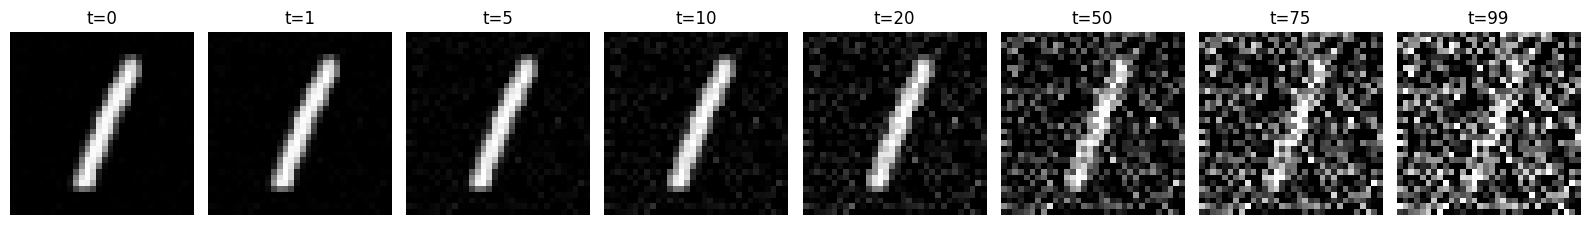

In [9]:
x0_single = x_batch[0:1]
visual_timesteps = [0, 1, 5, 10, 20, 50, 75, 99]

noisy_images = []
titles = []

fixed_noise = torch.randn_like(x0_single)

for t_value in visual_timesteps:
    t_tensor = torch.tensor([t_value], dtype=torch.long)
    xt = q_sample(x0_single, t_tensor, noise=fixed_noise)
    noisy_images.append(xt)
    titles.append(f"t={t_value}")

show_images(torch.cat(noisy_images, dim=0), titles=titles, figsize=(16, 3))

You should observe a gradual transition:

```text
clean → slightly noisy → heavily noisy → mostly noise
```

At late timesteps, the image contains much less information about the original example because $\bar\alpha_t$ has become small.

# 18. Multiple Images at Multiple Timesteps

The same rule is applied independently to every sample. To make that visible, we will place different MNIST examples in rows and timesteps in columns.

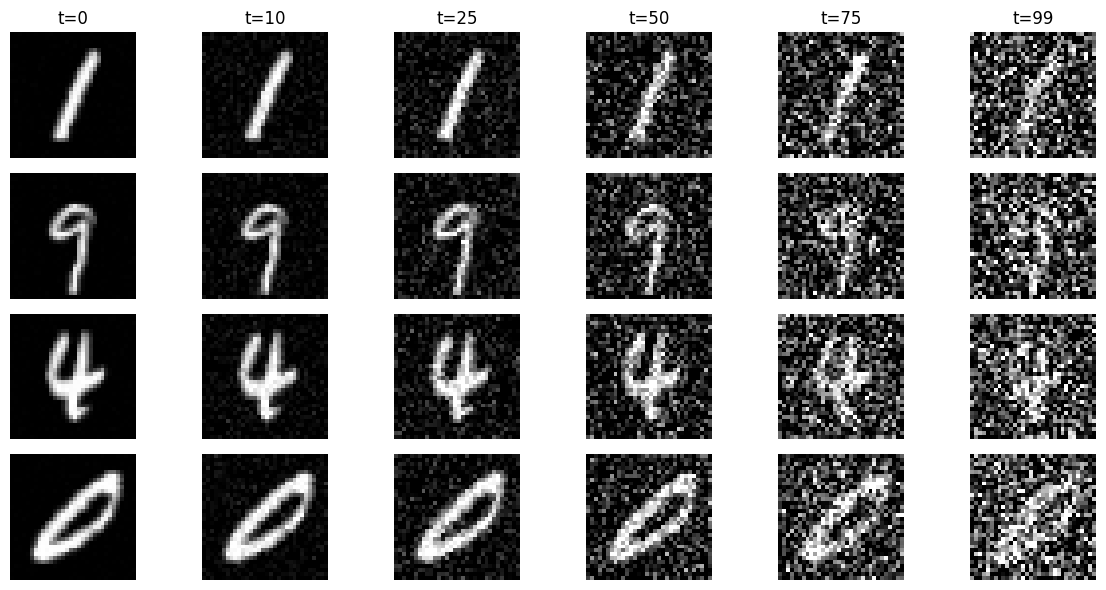

In [10]:
def show_timestep_grid(images_by_timestep, timesteps, figsize=(14, 7)):
    """Show rows = examples, columns = timesteps."""
    tensor = torch.stack(images_by_timestep, dim=1)  # [B, K, C, H, W]
    tensor = tensor.detach().cpu().clamp(-1, 1)
    tensor = (tensor + 1.0) / 2.0

    batch_size, num_steps = tensor.shape[:2]
    fig, axes = plt.subplots(batch_size, num_steps, figsize=figsize, squeeze=False)

    for row in range(batch_size):
        for col in range(num_steps):
            axes[row, col].imshow(tensor[row, col].squeeze(0), cmap="gray", vmin=0, vmax=1)
            axes[row, col].axis("off")
            if row == 0:
                axes[row, col].set_title(f"t={timesteps[col]}")

    plt.tight_layout()
    plt.show()

selected = x_batch[:4]
timestep_grid = [0, 10, 25, 50, 75, 99]

grid_images = []
for t_value in timestep_grid:
    t_tensor = torch.full((selected.shape[0],), t_value, dtype=torch.long)
    grid_images.append(q_sample(selected, t_tensor))

show_timestep_grid(grid_images, timestep_grid, figsize=(12, 6))

# 19. Noise Schedule Visualization

The schedule controls how signal and noise evolve over time.

We will inspect four related quantities:

```text
β_t
α_t
ᾱ_t
1 - ᾱ_t
```

Interpret them as:

- **β_t:** how much new noise variance is introduced at step `t`.
- **α_t:** how much signal is retained locally.
- **ᾱ_t:** how much original signal survives cumulatively.
- **1 - ᾱ_t:** how much cumulative noise variance has accumulated.

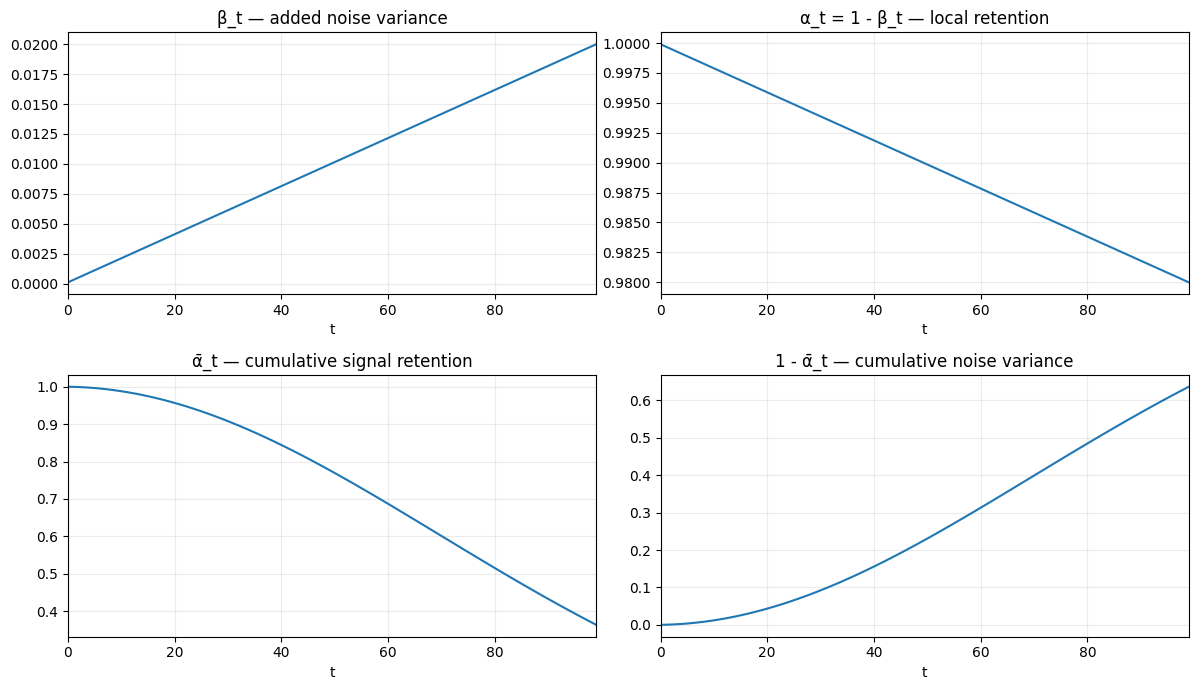

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(12, 7))

axes[0, 0].plot(betas.numpy())
axes[0, 0].set_title("β_t — added noise variance")
axes[0, 0].set_xlabel("t")

axes[0, 1].plot(alphas.numpy())
axes[0, 1].set_title("α_t = 1 - β_t — local retention")
axes[0, 1].set_xlabel("t")

axes[1, 0].plot(alpha_bars.numpy())
axes[1, 0].set_title("ᾱ_t — cumulative signal retention")
axes[1, 0].set_xlabel("t")

axes[1, 1].plot((1.0 - alpha_bars).numpy())
axes[1, 1].set_title("1 - ᾱ_t — cumulative noise variance")
axes[1, 1].set_xlabel("t")

for ax in axes.flat:
    ax.grid(alpha=0.25)
    ax.set_xlim(0, T - 1)

plt.tight_layout()
plt.show()

# 20. Signal vs Noise Interpretation

The closed-form equation can be read as two explicit components:

$$
x_t = \underbrace{\sqrt{\bar\alpha_t}x_0}_{\text{signal}} + \underbrace{\sqrt{1-\bar\alpha_t}\epsilon}_{\text{noise}}
$$

So the coefficients multiplying the two terms are:

```text
early t:
√ᾱ_t          high
√(1-ᾱ_t)      low

late t:
√ᾱ_t          low
√(1-ᾱ_t)      high
```

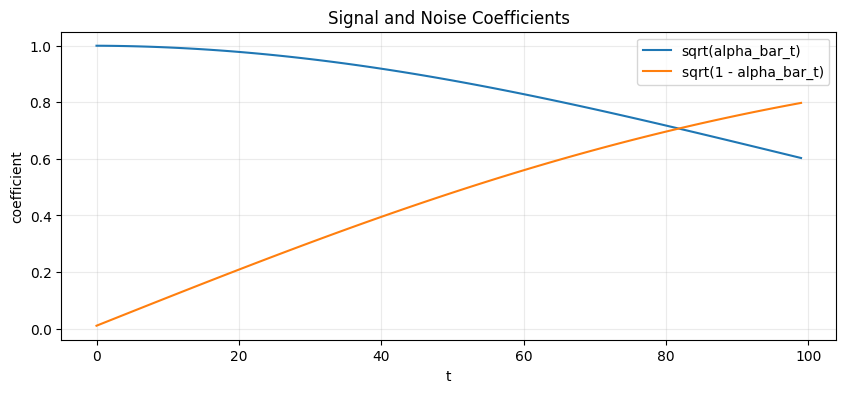

In [12]:
signal_coeff = sqrt_alpha_bars.numpy()
noise_coeff = sqrt_one_minus_alpha_bars.numpy()

plt.figure(figsize=(10, 4))
plt.plot(signal_coeff, label="sqrt(alpha_bar_t)")
plt.plot(noise_coeff, label="sqrt(1 - alpha_bar_t)")
plt.xlabel("t")
plt.ylabel("coefficient")
plt.title("Signal and Noise Coefficients")
plt.grid(alpha=0.25)
plt.legend()
plt.show()

# 21. Why the Closed Form Matters

Without the closed form, producing `x_t` could mean simulating every transition:

```text
x₀ → x₁ → x₂ → ... → x_t
```

But after the derivation, we can jump directly:

$$
x_t = \sqrt{\bar\alpha_t}x_0 + \sqrt{1-\bar\alpha_t}\epsilon
$$

```text
x₀ ───────────────→ x_t
```

This matters during training because we can randomly choose a timestep `t` and construct its noisy sample in one shot.

# 22. The Reverse Process

Now switch perspectives.

Forward process:

```text
q:
data → noise
```

Reverse process:

```text
p_θ:
noise → data
```

The reverse transition is written as:

$$
p_\theta(x_{t-1}\mid x_t)
$$

The distinction is crucial:

> **`q` is the fixed forward corruption process. `p_θ` is the learned reverse process.**

# 23. Reverse Markov Chain

The complete reverse generative model can be factorized as:

$$
p_\theta(x_{0:T}) = p(x_T)\prod_{t=1}^{T}p_\theta(x_{t-1}\mid x_t)
$$

Conceptually:

```text
x_T ~ N(0, I)
        ↓
p_θ(x_{T-1} | x_T)
        ↓
x_{T-1}
        ↓
      ...
        ↓
x₁
        ↓
p_θ(x₀ | x₁)
        ↓
x₀
```

The final result is a generated sample in the data space.

# 24. Why the Reverse Process Is Learned

We design the forward process, so we know:

$$
q(x_t\mid x_{t-1})
$$

But during generation we need:

$$
p_\theta(x_{t-1}\mid x_t)
$$

That reverse transition is not simply given to us. A neural network learns a rule for reversing the corruption at each timestep.

# 25. Gaussian Reverse Transition

A common form is:

$$
p_\theta(x_{t-1}\mid x_t)=\mathcal N\left(x_{t-1};\mu_\theta(x_t,t),\Sigma_t\right)
$$

The roles are:

```text
x_t       = current noisy sample

t         = noise level / timestep
μ_θ       = learned reverse-step mean
Σ_t       = reverse-step covariance choice
```

Notebook 07 will turn this probabilistic idea into an actual sampler.

# 26. Why Does the Model Need `t`?

The same tensor shape can represent very different noise levels.

An early timestep might mean:

```text
mostly clean image + a little noise
```

while a late timestep might mean:

```text
almost pure noise
```

So the network must know which denoising problem it is solving.

```text
(x_t, t)
   ↓
"How much corruption am I looking at?"
   ↓
denote the appropriate denoising behavior
```

This is why diffusion models use timestep conditioning.

# 27. Predicting Noise Instead of Directly Predicting $x_0$

A common DDPM parameterization is a noise-prediction network:

$$
\epsilon_\theta(x_t,t)
$$

Instead of directly asking the network for a clean image, we ask it to predict the Gaussian noise that produced the current noisy sample.

Start from the closed form:

$$
x_t=\sqrt{\bar\alpha_t}x_0+\sqrt{1-\bar\alpha_t}\epsilon
$$

Replace the unknown noise with the model prediction $\epsilon_\theta(x_t,t)$ and solve for $x_0$:

$$
\boxed{
\hat{x}_0 = \frac{x_t-\sqrt{1-\bar\alpha_t}\,\epsilon_\theta(x_t,t)}{\sqrt{\bar\alpha_t}}
}
$$

Every term has a clear role:

```text
x_t                         noisy observation
ε_θ(x_t, t)                 predicted corruption
√(1-ᾱ_t)                   noise coefficient at timestep t
√ᾱ_t                       signal coefficient at timestep t
x̂₀                         estimated clean sample
```

# 28. Tiny Noise-Prediction Example

Use a scalar example to connect the algebra to numbers.

Suppose we know:

```text
x_t          = 1.2
ᾱ_t         = 0.64
predicted ε  = 0.3
```

Then:

$$
\hat{x}_0 = \frac{1.2-\sqrt{1-0.64}(0.3)}{\sqrt{0.64}}
$$

This is **not** a trained diffusion model. It is only a numerical check showing how noise prediction can be converted into an estimate of the clean input.

In [13]:
xt_scalar = 1.2
alpha_bar_scalar = 0.64
epsilon_hat_scalar = 0.3

x0_hat_scalar = (
    xt_scalar - math.sqrt(1.0 - alpha_bar_scalar) * epsilon_hat_scalar
) / math.sqrt(alpha_bar_scalar)

print(f"x_t = {xt_scalar}")
print(f"alpha_bar_t = {alpha_bar_scalar}")
print(f"predicted epsilon = {epsilon_hat_scalar}")
print(f"estimated x0 = {x0_hat_scalar:.4f}")

x_t = 1.2
alpha_bar_t = 0.64
predicted epsilon = 0.3
estimated x0 = 1.2750


# 29. Variational View — Why Does ELBO Appear?

Diffusion can be described with latent intermediate states:

```text
x₀, x₁, ..., x_T
```

The marginal data likelihood is conceptually:

$$
p_\theta(x_0)=\int p_\theta(x_{0:T})\,dx_1\cdots dx_T
$$

The problem is that this high-dimensional marginalization is difficult to evaluate directly.

A variational distribution gives us a tractable route:

$$
q(x_{1:T}\mid x_0)
$$

and an evidence lower bound (ELBO):

$$
\log p_\theta(x_0)
\ge
\mathbb E_q\left[\log p_\theta(x_{0:T})-\log q(x_{1:T}\mid x_0)\right]
$$

The important conceptual chain is:

```text
maximum likelihood
        ↓
intractable marginal likelihood
        ↓
variational bound
        ↓
tractable training formulation
```

We do **not** need the full DDPM ELBO derivation yet. The goal here is to know why a variational objective appears at all.

# 30. Connecting ELBO to the Simple DDPM Objective

The commonly used simplified DDPM objective is:

$$
L_{\text{simple}}
=
\mathbb E_{x_0,\epsilon,t}
\left[
\left\|\epsilon-\epsilon_\theta(x_t,t)\right\|^2
\right]
$$

The training story becomes:

```text
sample clean x₀
      ↓
sample timestep t
      ↓
sample Gaussian noise ε
      ↓
construct x_t
      ↓
ε_θ(x_t, t)
      ↓
compare prediction with true ε
      ↓
MSE loss
```

This MSE is the standard simplified DDPM objective derived from the variational formulation under the usual parameterization. It is better to say **simplified DDPM objective** than to casually equate it with the entire ELBO.

# 31. End-to-End Training Concept — No Full Training Yet

The full conceptual training loop is now visible:

```text
sample x₀
   ↓
sample random timestep t
   ↓
sample Gaussian noise ε
   ↓
construct x_t using q_sample
   ↓
predict ε_θ(x_t, t)
   ↓
compare ε̂ with ε
   ↓
MSE loss
   ↓
update network
```

This notebook stops before the neural network and optimizer.

Notebook 07 will implement:

```text
U-Net
 ↓
Time Embedding
 ↓
Noise Prediction
 ↓
Training Loop
 ↓
Reverse Sampling
 ↓
Generated Images
```

# 32. `q` vs `p_θ` Summary

| Property | Forward `q` | Reverse `p_θ` |
|---|---|---|
| Direction | data → noise | noise → data |
| Learned? | No | Yes |
| Purpose | corrupt data | generate data |
| Typical transition | $q(x_t\mid x_{t-1})$ | $p_\theta(x_{t-1}\mid x_t)$ |
| Main ingredient | fixed schedule | neural network |

# 33. What Diffusion Is Really Learning

A useful mental correction is:

Diffusion is **not** simply learning:

```text
noise → image
```

in one giant jump.

Instead, it learns a family of conditional denoising behaviors:

```text
(x_t, t)
   ↓
predict how the corruption should be reversed
```

So:

```text
same x_t shape
      +
different t
      ↓
different denoising task
```

The timestep is part of the input because the noise level changes throughout the chain.

# 34. Diffusion vs VAE vs GAN

| Model | Main idea |
|---|---|
| VAE | encode → latent → decode |
| GAN | generator vs discriminator |
| Diffusion | iterative denoising |

Compactly:

```text
VAE:
x → z → x̂

GAN:
z → G(z)

Diffusion:
x₀ → noisy states
and
x_T → x₀
```

Diffusion generation is therefore an **iterative stochastic process**, not a single forward pass from one latent vector to one image.

# 35. Diffusion vs Denoising Autoencoder

| Denoising Autoencoder | Diffusion |
|---|---|
| often one corruption level or a family of corruptions | explicit sequence of noise levels |
| noisy → clean | $x_T → ... → x_0$ |
| denoising network | learned reverse transitions |
| not automatically a full generative chain | explicitly designed as a generative process |

The connection is conceptual: diffusion can be understood as turning denoising into a structured sequence of small conditional problems.

# 36. Important Clarification — Diffusion Is Not “Just Adding Noise”

Adding Gaussian noise is only the **forward corruption mechanism**.

The interesting generative component is what happens in reverse:

```text
forward corruption
        +
learned reverse denoising
        =
generative model
```

Without the learned reverse process, we only have a corruption process that destroys information.

# 37. Experiment — Change `T`

Changing the number of diffusion steps changes how the same overall idea is discretized.

We will only compare the cumulative signal curve. This is a visualization experiment, not a claim that one value of `T` is universally best.

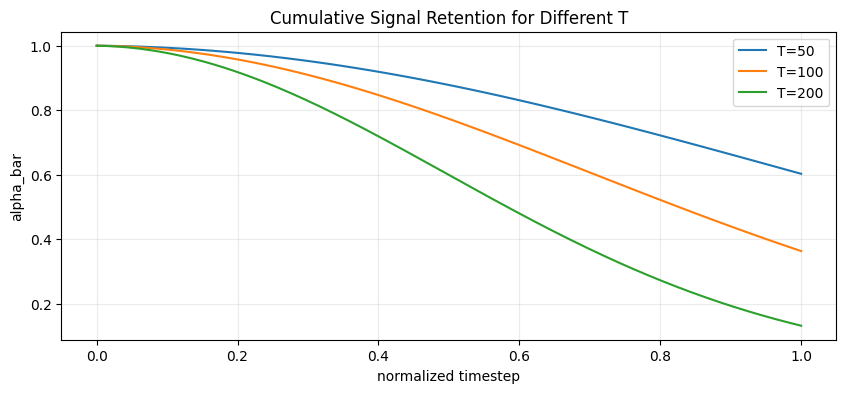

In [14]:
def linear_schedule(num_steps, beta_start=1e-4, beta_end=0.02):
    betas_local = torch.linspace(beta_start, beta_end, num_steps)
    alphas_local = 1.0 - betas_local
    alpha_bars_local = torch.cumprod(alphas_local, dim=0)
    return betas_local, alphas_local, alpha_bars_local

plt.figure(figsize=(10, 4))
for num_steps in [50, 100, 200]:
    _, _, alpha_bars_local = linear_schedule(num_steps)
    plt.plot(
        np.linspace(0, 1, num_steps),
        alpha_bars_local.numpy(),
        label=f"T={num_steps}",
    )

plt.xlabel("normalized timestep")
plt.ylabel("alpha_bar")
plt.title("Cumulative Signal Retention for Different T")
plt.grid(alpha=0.25)
plt.legend()
plt.show()

Notice that changing `T` changes the sequence of intermediate noise levels. It is useful to think of `T` as the number of discrete points used to represent the diffusion path.

# 38. Experiment — Compare a Linear and Cosine-Inspired Schedule

A different schedule changes **how quickly** signal is removed.

The goal here is only to see the effect on $\bar\alpha_t$. We use a compact cosine-inspired construction for visualization; this is not a production schedule implementation.

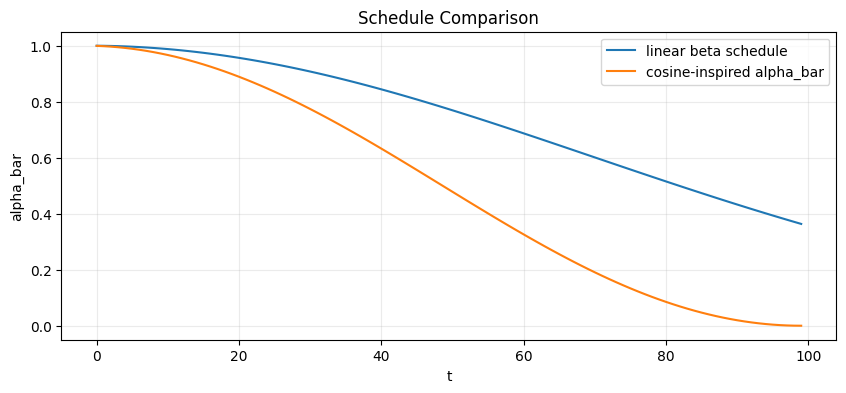

In [15]:
def cosine_inspired_alpha_bars(num_steps, s=0.008):
    # Compact visualization-only form inspired by cosine schedules.
    steps = torch.arange(num_steps + 1, dtype=torch.float32)
    f = torch.cos(((steps / num_steps) + s) / (1.0 + s) * math.pi / 2.0) ** 2
    f = f / f[0]
    return f[1:].clamp(min=1e-6, max=1.0)

_, _, alpha_bars_linear = linear_schedule(T)
alpha_bars_cosine = cosine_inspired_alpha_bars(T)

plt.figure(figsize=(10, 4))
plt.plot(alpha_bars_linear.numpy(), label="linear beta schedule")
plt.plot(alpha_bars_cosine.numpy(), label="cosine-inspired alpha_bar")
plt.xlabel("t")
plt.ylabel("alpha_bar")
plt.title("Schedule Comparison")
plt.grid(alpha=0.25)
plt.legend()
plt.show()

The schedule is a control knob over the signal-to-noise trajectory. Different schedules can distribute corruption differently across the timestep range.

# 39. Sanity Checks

A diffusion implementation should contain small checks that catch notation or shape mistakes early.

In [16]:
# Schedule checks
assert torch.all(betas > 0)
assert torch.all(betas < 1)
assert torch.all(alpha_bars > 0)
assert torch.all(alpha_bars <= 1)
assert torch.allclose(alphas, 1.0 - betas)

# Shape checks
x0_check = torch.randn(8, 1, 32, 32)
t_check = torch.randint(0, T, (8,), dtype=torch.long)
noise_check = torch.randn_like(x0_check)
xt_check = q_sample(x0_check, t_check, noise_check)

assert x0_check.shape == noise_check.shape == xt_check.shape
assert extract(alpha_bars, t_check, x0_check.shape).shape == (8, 1, 1, 1)

print("All diffusion schedule and shape sanity checks passed.")

All diffusion schedule and shape sanity checks passed.


# 40. Numerical Verification of the $t=2$ Derivation

The algebra says that:

$$
\sqrt{\alpha_2(1-\alpha_1)}\epsilon_1 + \sqrt{1-\alpha_2}\epsilon_2
$$

has the same Gaussian distribution as:

$$
\sqrt{1-\alpha_1\alpha_2}\epsilon
$$

for a standard Gaussian $\epsilon$.

A distributional statement does not mean the two values are identical sample-by-sample. We can instead verify that their empirical mean and variance are close.

In [17]:
num_samples = 100_000
alpha1 = 0.9
alpha2 = 0.8

rng = torch.Generator().manual_seed(SEED)
eps1 = torch.randn(num_samples, generator=rng)
eps2 = torch.randn(num_samples, generator=rng)
eps = torch.randn(num_samples, generator=rng)

combined = math.sqrt(alpha2 * (1.0 - alpha1)) * eps1 + math.sqrt(1.0 - alpha2) * eps2
collapsed = math.sqrt(1.0 - alpha1 * alpha2) * eps

print("Combined mean / variance :", combined.mean().item(), combined.var(unbiased=True).item())
print("Collapsed mean / variance:", collapsed.mean().item(), collapsed.var(unbiased=True).item())
print("Target variance           :", 1.0 - alpha1 * alpha2)

assert abs(combined.var(unbiased=True).item() - (1.0 - alpha1 * alpha2)) < 0.02

Combined mean / variance : -0.0007846414810046554 0.281210720539093
Collapsed mean / variance: -0.001398491207510233 0.28033649921417236
Target variance           : 0.2799999999999999


# 41. Common Mistakes

### Mistake 1 — Confusing $\beta_t$ and $\sqrt{\beta_t}$

```text
β_t       = variance
√β_t      = standard-deviation coefficient
```

### Mistake 2 — Confusing $\alpha_t$ and $\bar\alpha_t$

```text
α_t       = local retention
ᾱ_t      = cumulative retention
```

### Mistake 3 — Forgetting the square roots

Wrong:

$$
\bar\alpha_t x_0 + (1-\bar\alpha_t)\epsilon
$$

Correct:

$$
\sqrt{\bar\alpha_t}x_0+\sqrt{1-\bar\alpha_t}\epsilon
$$

### Mistake 4 — Keeping many independent noise terms in the final closed form

The recursive expression contains multiple Gaussian terms, but their weighted sum is Gaussian. The closed form can represent that total noise with one standard Gaussian variable.

### Mistake 5 — Confusing `q` and `p_θ`

```text
q     = fixed forward process
p_θ   = learned reverse process
```

### Mistake 6 — Forgetting that `t` matters

The model sees different noise levels at different timesteps, so the denoising task changes with `t`.

### Mistake 7 — Thinking diffusion is one giant noise-to-image mapping

The generative process is usually a sequence of reverse transitions rather than one direct jump.

# 42. Final Mental Model

## Forward diffusion

```text
x₀ → x₁ → x₂ → ... → x_T
```

## Reverse diffusion

```text
x_T → x_{T-1} → ... → x₁ → x₀
```

## Training idea

```text
x₀
 ↓
choose t
 ↓
sample ε
 ↓
create x_t
 ↓
predict ε_θ(x_t,t)
 ↓
MSE with true ε
```

## Mathematical core

$$
q(x_t\mid x_{t-1})
=
\mathcal N\left(\sqrt{\alpha_t}x_{t-1},(1-\alpha_t)I\right)
$$

$$
\bar\alpha_t=\prod_{s=1}^{t}\alpha_s
$$

$$
x_t=\sqrt{\bar\alpha_t}x_0+\sqrt{1-\bar\alpha_t}\epsilon
$$

$$
\hat x_0
=
\frac{x_t-\sqrt{1-\bar\alpha_t}\epsilon_\theta(x_t,t)}{\sqrt{\bar\alpha_t}}
$$

$$
L_{\text{simple}}
=
\mathbb E\left[\|\epsilon-\epsilon_\theta(x_t,t)\|^2\right]
$$

# 43. Preview of Notebook 07

Notebook 06:

> **Understand the mathematics.**

Notebook 07:

> **Build the model.**

The next notebook will connect the equations to a working DDPM:

```text
U-Net
 ↓
Time Embedding
 ↓
Noise Prediction
 ↓
Training Loop
 ↓
Reverse Sampling
 ↓
Generated Images
```

The forward-process mathematics from this notebook will become the fixed part of the training pipeline, while the neural network will learn the reverse denoising behavior.

# 44. Try It Yourself

1. Change `T` and inspect how $\bar\alpha_t$ changes.
2. Change `BETA_END` and re-plot the schedule.
3. Plot $\sqrt{\bar\alpha_t}$ for multiple schedules.
4. Visualize the same image at different timesteps.
5. Compare the linear and cosine-inspired schedules.
6. Verify the $t=2$ derivation numerically with different $\alpha_1,\alpha_2$ values.
7. Generate two independent Gaussian noise terms and verify that their weighted sum behaves approximately like one Gaussian with the predicted variance.
8. Compute $x_t$ manually for a scalar example.
9. Recover $x_0$ from a known $x_t$, $\bar\alpha_t$, and known noise.
10. Explain, in your own words, why the denoising network must receive the timestep `t`.

---

## Takeaway

The core idea is simple once the symbols are connected:

```text
β_t controls added noise variance
        ↓
α_t = 1 - β_t controls local signal retention
        ↓
ᾱ_t = Π α_s controls cumulative signal retention
        ↓
q(x_t | x₀) gives a direct jump to any noise level
        ↓
ε_θ(x_t, t) learns the reverse denoising behavior
```

The next step is not more notation. It is implementation: **turn these equations into a trainable DDPM.**